# Регрессия: IC50

IC50 — концентрация ингибирования 50% вирусной активности. Хотим предсказать это число по молекулярным дескрипторам.

Начну с простых моделей, потом попробую ансамбли.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [ ]:
df = pd.read_excel('/content/Данные_для_курсовои_Классическое_МО (1).xlsx', index_col=0)

targets = ['IC50, mM', 'CC50, mM', 'SI']
features = [c for c in df.columns if c not in targets]

X = df[features]
y = np.log1p(df['IC50, mM'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Train: 800, Test: 201


In [ ]:
X_train.isna().sum().sum()

np.int64(24)

In [ ]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

Воспользуемся Ridge с Lasso как baseline. Они нужны для сравнения — чтобы понять, что ансамблевые методы (Random Forest, Gradient Boosting) работают лучше.

In [ ]:
# Ridge
pipe = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
print(f'Ridge: R² = {r2_score(y_test, pred):.3f}')

Ridge: R² = 0.278


In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = {}

### Ridge с подбором alpha

у нас 210 признаков, многие из них сильно коррелируют друг с другом (мы это в EDA видели). Обычная линейная регрессия в такой ситуации "сходит с ума" - коэффициенты становятся огромными и нестабильными. Ridge этот штраф добавляет и "успокаивает" коэффициенты.

Будем использовать GridSearchCV для автоматического подбора нужных параметров

In [ ]:
param_grid = {'model__alpha': [0.01, 0.1, 1, 10, 100, 500]}
gs = GridSearchCV(Pipeline([('scaler', StandardScaler()), ('model', Ridge())]),
                  param_grid, cv=5, scoring='r2', n_jobs=-1)
gs.fit(X_train, y_train)
pred = gs.predict(X_test)

results['Ridge'] = {'R2': r2_score(y_test, pred), 'RMSE': rmse(y_test, pred)}
print(f'Best alpha: {gs.best_params_}')
print(f'R² = {results["Ridge"]["R2"]:.3f}, RMSE = {results["Ridge"]["RMSE"]:.3f}')

Best alpha: {'model__alpha': 500}
R² = 0.306, RMSE = 1.635


Линейная модель справляется слабо. Лучшая alpha = 500 - большой штраф, что говорит о сильной мультиколлинеарности признаков.

### Lasso

In [ ]:
gs_lasso = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('model', Lasso(max_iter=5000))]),
    {'model__alpha': [0.001, 0.01, 0.05, 0.1, 0.5]},
    cv=5, scoring='r2', n_jobs=-1)
gs_lasso.fit(X_train, y_train)
pred_lasso = gs_lasso.predict(X_test)

results['Lasso'] = {'R2': r2_score(y_test, pred_lasso), 'RMSE': rmse(y_test, pred_lasso)}

# сколько признаков осталось
coef = gs_lasso.best_estimator_['model'].coef_
print(f'Признаков с ненулевым коэффициентом: {(coef != 0).sum()} из {len(coef)}')
print(f'R² = {results["Lasso"]["R2"]:.3f}, RMSE = {results["Lasso"]["RMSE"]:.3f}')

Признаков с ненулевым коэффициентом: 49 из 210
R² = 0.297, RMSE = 1.645


Чуть хуже Ridge, но автоматически отобрал только 50 признаков из 211 - то есть большинство признаков оказались неинформативными для линейной модели.

### Random Forest

In [ ]:
gs_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    {'n_estimators': [100, 200], 'max_depth': [None, 15], 'min_samples_leaf': [1, 2]},
    cv=5, scoring='r2', n_jobs=-1)
gs_rf.fit(X_train, y_train)
pred_rf = gs_rf.predict(X_test)

results['Random Forest'] = {'R2': r2_score(y_test, pred_rf), 'RMSE': rmse(y_test, pred_rf)}
print(f'Best: {gs_rf.best_params_}')
print(f'R² = {results["Random Forest"]["R2"]:.3f}')

Best: {'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 200}
R² = 0.450


Заметно лучше линейных моделей — нелинейные зависимости между признаками и IC50 существуют.

### Gradient Boosting

In [ ]:
gs_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 4]},
    cv=5, scoring='r2', n_jobs=-1)
gs_gb.fit(X_train, y_train)
pred_gb = gs_gb.predict(X_test)

results['Gradient Boosting'] = {'R2': r2_score(y_test, pred_gb), 'RMSE': rmse(y_test, pred_gb)}
print(f'Best: {gs_gb.best_params_}')
print(f'R² = {results["Gradient Boosting"]["R2"]:.3f}')

Best: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
R² = 0.444


Хороший результат, но чуть хуже Random Forest.

## Сравнение

                       R2    RMSE
Random Forest      0.4497  1.4554
Gradient Boosting  0.4441  1.4628
Ridge              0.3056  1.6348
Lasso              0.2967  1.6453


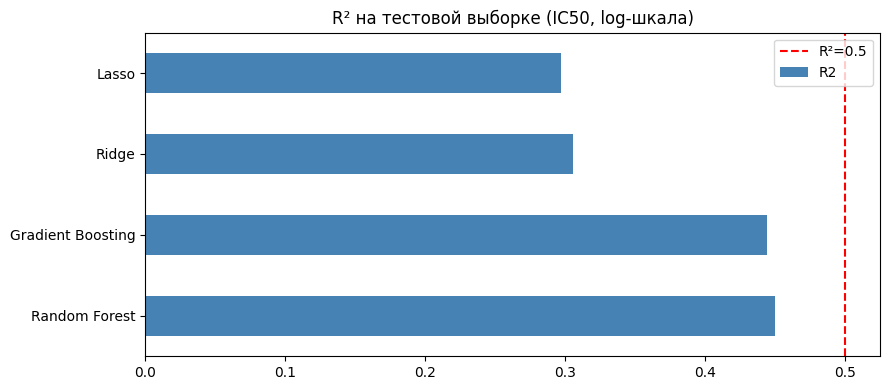

In [ ]:
res_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print(res_df.round(4))

res_df['R2'].plot(kind='barh', figsize=(9, 4), color='steelblue')
plt.axvline(0.5, color='red', linestyle='--', label='R²=0.5')
plt.title('R² на тестовой выборке (IC50, log-шкала)')
plt.legend()
plt.tight_layout()
plt.show()

### Анализ ошибок лучшей модели

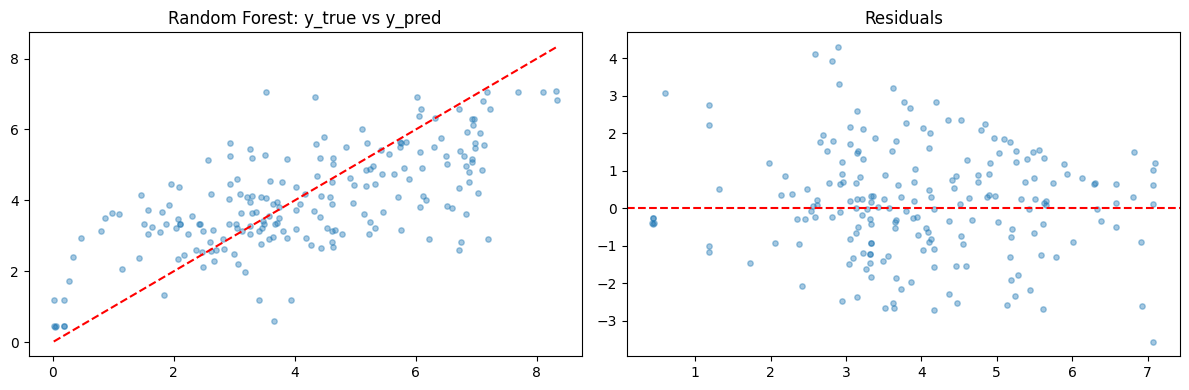

In [ ]:
best_pred = pred_rf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, best_pred, s=15, alpha=0.4)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--')
axes[0].set_title('Random Forest: y_true vs y_pred')

axes[1].scatter(best_pred, y_test - best_pred, s=15, alpha=0.4)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_title('Residuals')

plt.tight_layout()
plt.show()

График остатков показывает отсутствие систематической ошибки - модель не завышает и не занижает предсказания систематически. Большой разброс объясняется сложностью задачи и наличием нетипичных соединений.

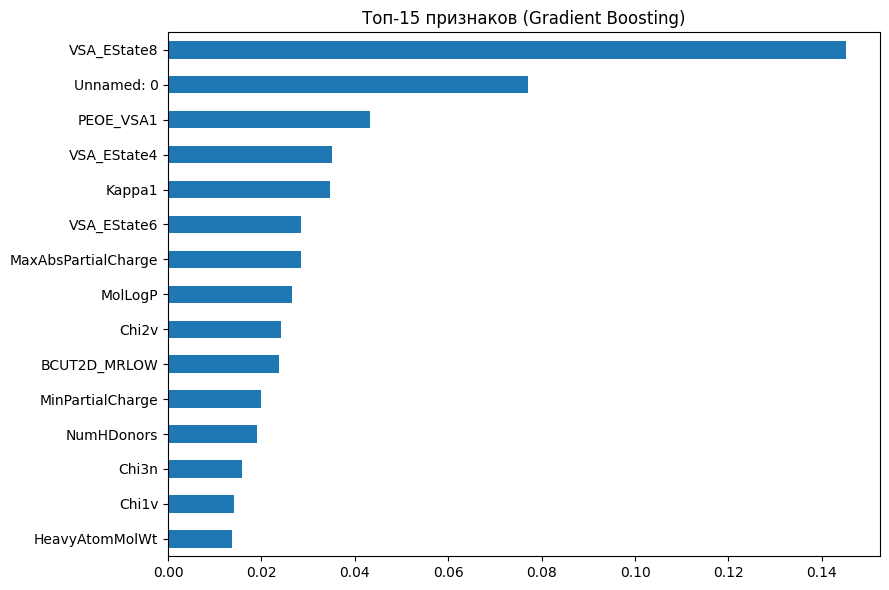

In [ ]:
model = gs_gb.best_estimator_

imp = pd.Series(model.feature_importances_, index=features)

imp.nlargest(15)[::-1].plot(kind='barh', figsize=(9, 6))

plt.title('Топ-15 признаков (Gradient Boosting)')
plt.tight_layout()
plt.show()

## Вывод

Лучшей моделью для предсказания IC50 оказался Random Forest с R² = 0.450. В целом R² невысокий — это ожидаемо, так как IC50 зависит от сложных нелинейных взаимодействий молекулярных признаков. Линейные модели (Ridge, Lasso) показали значительно более слабый результат, что подтверждает нелинейный характер зависимости. Lasso при этом полезен для отбора признаков - он оставил только 49 из 211.
